In [1]:
# --------------------------------------------------------
# explor estimatet Seas searfscae temp SSTs
# --------------------------------------------------------
# import relevant modules first
import os
print(os.getcwd())          # aktuelles Verzeichnis
print(os.listdir("../")) 
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
from scipy.stats import linregress
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.dates as mdates
import datetime

# help functions from data_prep:
from pathlib import Path
import sys
project_root = Path.cwd().parent   # adjust if needed
sys.path.append(str(project_root))
print(project_root)

import importlib
import importlib
import help_func as help_func  # Modul importieren
# Änderungen in help_func.py werden geladen
importlib.reload(help_func)
from help_func import * # importiere alle funktionen

# ecBH_glc one nc file pro station, pro zeitschritt - 
# flc sind sind zeitschritte in dem satelllite niedrige wolke erkannt wurde
# costelmet CM - ist am nächsten an der Küste mit zuverlässigen feuchte daten, 
# näher an der Küste feuchtigkeits date nicht zu gebrauchen, da salzkruste 

# for ridge regression analysis later on, anomaly calcualtioan and detrending 


# stations
stations = {
    "CM":  (-23.06, 14.63),
    "KB":  (-22.99, 14.74),
    "SH":  (-23.01, 14.89),
    "MK":  (-22.97, 14.99),
    "VF":  (-23.10, 15.03),
    "GB":  (-23.56, 15.04),
    "AU":  (-23.44, 15.05),
    "S8":  (-23.27, 15.06),
    "GK":  (-23.12, 15.31)
}

# Ordner erstellen, falls er nicht existiert
output_dir = "figures-01-SST"
os.makedirs(output_dir, exist_ok=True)  # exist_ok=True → kein Fehler, wenn Ordner schon da ist

c:\Users\maiim\Documents\25-26WS\Umweltfernerkundung\Phosphate\R-scripts\Pyhton
['01_dataPREP.R', '02_GABES.R', '2014Valid-outputs', '2014_vaildation.R', 'GABES-outputs', 'hel-func.R', 'outputs', 'overview.R', 'Pyhton', 'SST.R']
c:\Users\maiim\Documents\25-26WS\Umweltfernerkundung\Phosphate\R-scripts


ModuleNotFoundError: No module named 'help_func'

In [2]:
# load new SST data, higher resoltuion (monthly)
# define the path to the data
dirCFF = "C:/Users/maiim/Documents/25-26WS/SeminarProject_RemSen/data/newSSTs_noaa/"

SST_monthly = xr.open_dataset(dirCFF + "noaa_oisst_SEAnc.sec", engine="netcdf4")
SST_monthly_ex = xr.open_dataset(dirCFF + "noaa_oisst_SEA_expandednc.sec", engine="netcdf4")

In [3]:
print(SST_monthly)
print(SST_monthly_ex)

<xarray.Dataset> Size: 13MB
Dimensions:  (time: 252, lat: 160, lon: 80)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-07-01 2003-08-01 ... 2024-06-01
  * lat      (lat) float32 640B -44.88 -44.62 -44.38 ... -5.625 -5.375 -5.125
  * lon      (lon) float32 320B 0.125 0.375 0.625 0.875 ... 19.38 19.62 19.88
Data variables:
    sst      (time, lat, lon) float32 13MB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...
<xarray.Dataset> Size: 39MB
Dimensions:  (time: 252, lat: 240, lon: 160)
Coo

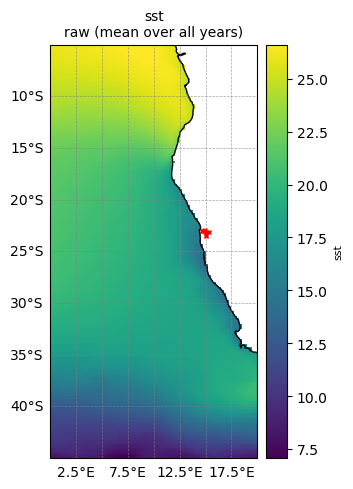

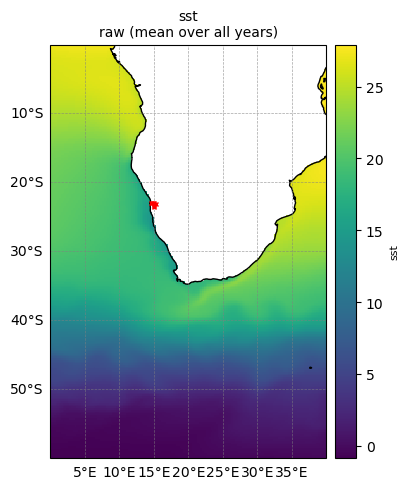

In [12]:
ds = SST_monthly
name = "raw (mean over all years)"
func_spatial_mean_CCF(ds, name, stations, single_var = True, y = 0, rec = False, text = False, showfig = True)

# specihern 
fig = func_spatial_mean_CCF(ds, name, stations, single_var = True, y = 0, rec = False, text = False, showfig = False)
fig.savefig(f"{output_dir}/SST_spatial_mean.png", dpi=300)
plt.close()

ds = SST_monthly_ex
name = "raw (mean over all years)"
func_spatial_mean_CCF(ds, name, stations, single_var = True, y = 0, rec = False, text = False, showfig = True)

# specihern 
fig = func_spatial_mean_CCF(ds, name, stations, single_var = True, y = 0, rec = False, text = False, showfig = False)
fig.savefig(f"{output_dir}/SST_spatial_mean_EXPAND.png", dpi=300)
plt.close()

c:\Users\maiim\Documents\25-26WS\SeminarProject_RemSen\Rem_Sen_project\scripts\help_func.py:1574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


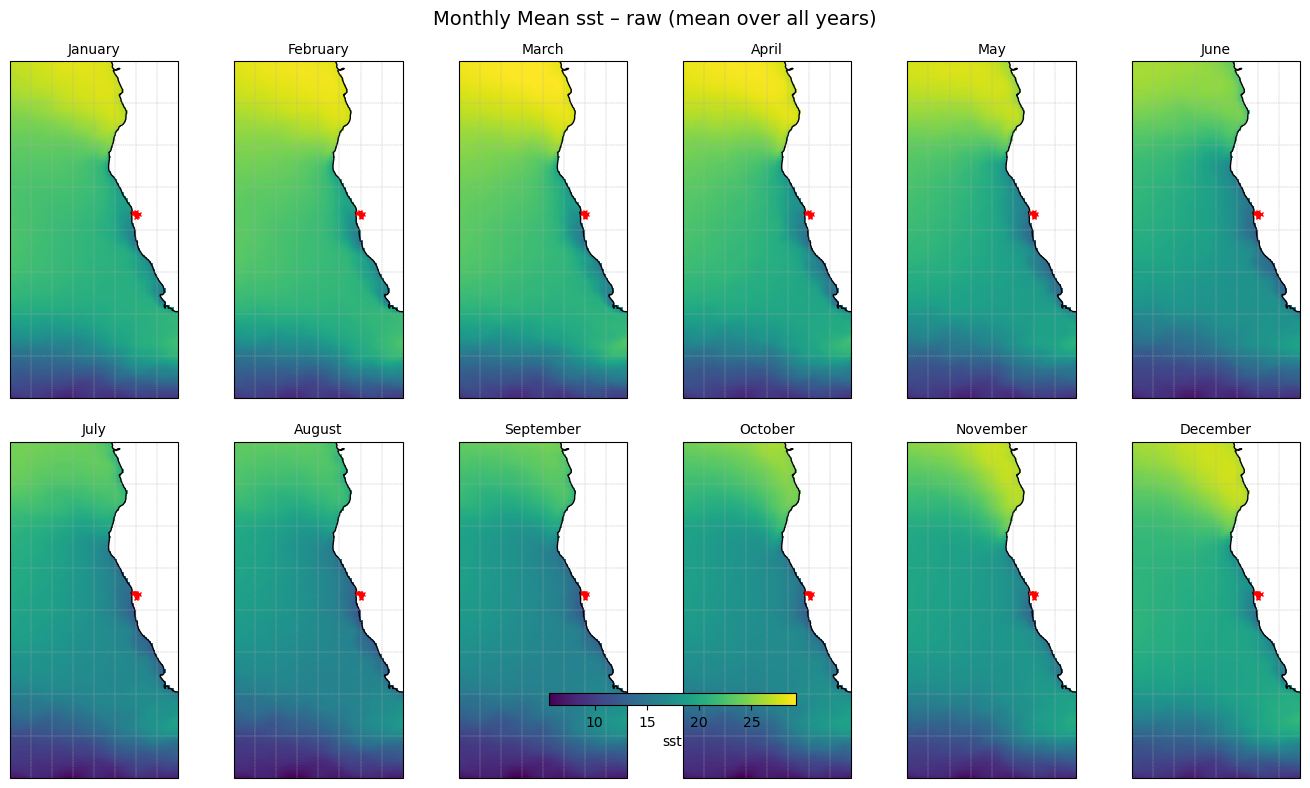

c:\Users\maiim\Documents\25-26WS\SeminarProject_RemSen\Rem_Sen_project\scripts\help_func.py:1574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\maiim\Documents\25-26WS\SeminarProject_RemSen\Rem_Sen_project\scripts\help_func.py:1574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


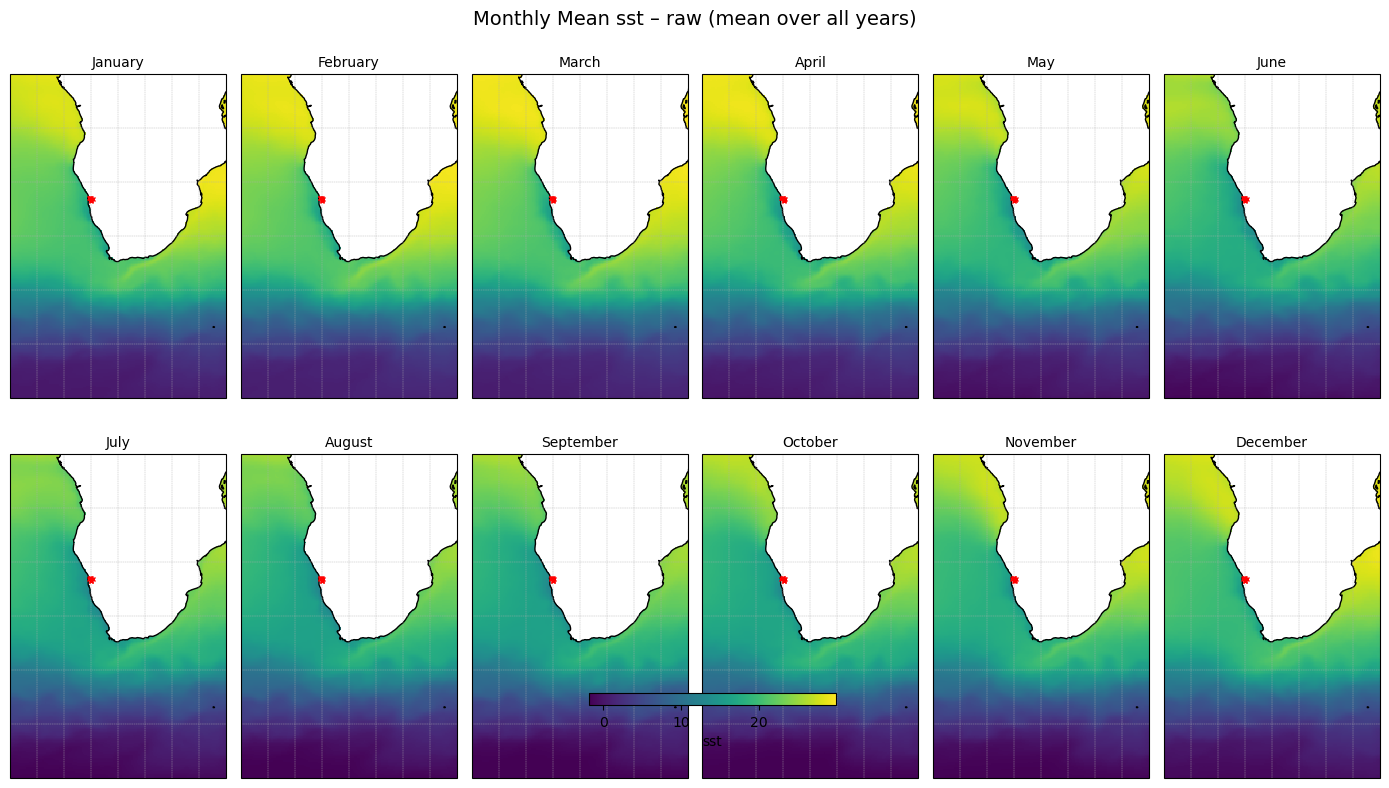

c:\Users\maiim\Documents\25-26WS\SeminarProject_RemSen\Rem_Sen_project\scripts\help_func.py:1574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [13]:
ds = SST_monthly
name = "raw (mean over all years)"
func_monhtly_mean_singleVAR_CCF(ds, name, stations, text = False, showfig=True)

# specihern 
fig = func_monhtly_mean_singleVAR_CCF(ds, name, stations, text = False, showfig=False)
fig.savefig(f"{output_dir}/SST_monthly_spatial_mean.png", dpi=300)
plt.close()

ds = SST_monthly_ex
name = "raw (mean over all years)"
func_monhtly_mean_singleVAR_CCF(ds, name, stations, text = False, showfig=True)

# specihern 
fig = func_monhtly_mean_singleVAR_CCF(ds, name, stations, text = False, showfig=False)
fig.savefig(f"{output_dir}/SST_monthly_spatial_mean_EXPAND.png", dpi=300)
plt.close()

In [53]:
print(SST_monthly)
print(SST_monthly.time[:5])

<xarray.Dataset> Size: 13MB
Dimensions:  (time: 252, lat: 160, lon: 80)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-07-01 2003-08-01 ... 2024-06-01
  * lat      (lat) float32 640B -44.88 -44.62 -44.38 ... -5.625 -5.375 -5.125
  * lon      (lon) float32 320B 0.125 0.375 0.625 0.875 ... 19.38 19.62 19.88
Data variables:
    sst      (time, lat, lon) float32 13MB 6.582 6.598 6.59 ... nan nan nan
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...
<xarray.DataArray 'time' (time: 5)> Size: 40B
a